<a href="https://colab.research.google.com/github/deepakvarghesevm/Case_Study_Starter_Notebook_Airbnb_NYC_Preprocessing_deepak_varghese.ipynb/blob/main/Case_Study_Supervised_Learning_deepak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [492]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [493]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [494]:
test_df = pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/ML MODEL/supervised /case_stuty_supervised_models_deepak/Testing_data.csv')
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [495]:
train_df = pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/ML MODEL/supervised /case_stuty_supervised_models_deepak/Training_data.csv')
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [496]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [497]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [498]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [499]:
train_df.duplicated().sum()

np.int64(0)

In [500]:
if "TotalCharges" in train_df.columns:
    train_df["TotalCharges"] = pd.to_numeric(
        train_df["TotalCharges"],
        errors="coerce"
    )

if "TotalCharges" in test_df.columns:
    test_df["TotalCharges"] = pd.to_numeric(
        test_df["TotalCharges"],
        errors="coerce"
    )

In [501]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [502]:
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


In [503]:
train_df[train_df["TotalCharges"].isnull()][["tenure","MonthlyCharges","TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
9,40,74.80,NaN
10,53,96.75,NaN
20,57,69.85,NaN
21,17,93.85,NaN
38,71,19.85,NaN
...,...,...,...
5567,39,NaN,NaN
5573,64,73.05,NaN
5578,65,92.70,NaN
5585,22,94.65,NaN


In [504]:
train_df['gender'] = train_df['gender'].fillna(train_df['gender'].mode()[0])
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0])
train_df['MonthlyCharges'] = train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median())
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['tenure'] * train_df['MonthlyCharges'])

In [505]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [506]:
train_df.drop('customerID', axis=1, inplace=True)

In [507]:
# import matplotlib.pyplot as plt
# columns = train_df.select_dtypes(include=['number']).columns
# for i in numeric_cols:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(train_df[i], bins=30, kde=True)
#     plt.title(f'Distribution of {i}')
#     plt.show()

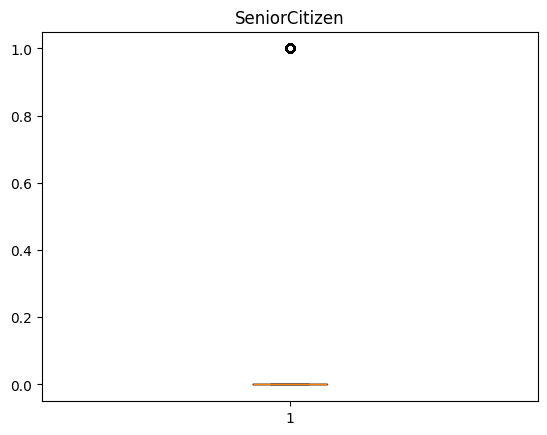

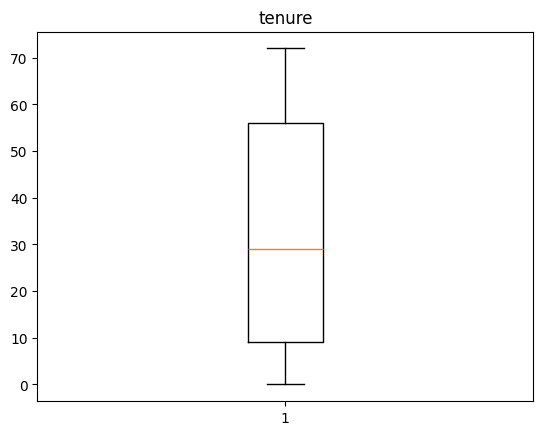

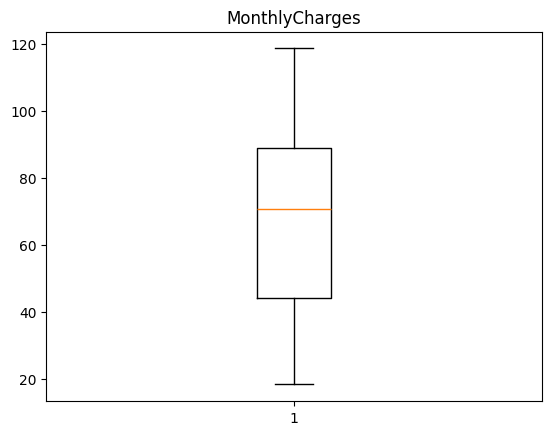

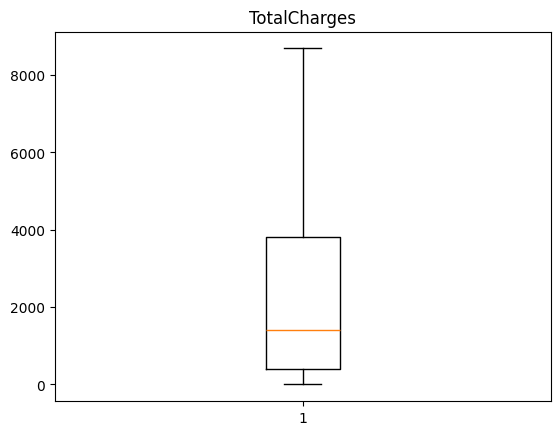

In [508]:
columns = train_df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(train_df[i])
  plt.title(i)
  plt.show()

In [509]:
train_df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,4734
1,900


In [510]:
# do manual mapping for all categorical values
train_df['gender'] = train_df['gender'].map({'Female':0,'Male':1})
train_df['Partner'] = train_df['Partner'].map({'No':0,'Yes':1})
train_df['Dependents'] = train_df['Dependents'].map({'No':0,'Yes':1})
train_df['PhoneService'] = train_df['PhoneService'].map({'No':0,'Yes':1})
train_df['PaperlessBilling'] = train_df['PaperlessBilling'].map({'No':0,'Yes':1})
train_df['Churn'] = train_df['Churn'].map({'No':0,'Yes':1})
train_df['MultipleLines'] = train_df['MultipleLines'].map({'No phone service':0,'No':1,'Yes':2})
train_df['InternetService'] = train_df['InternetService'].map({'No':0,'DSL':1,'Fiber optic':2})
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].map({'No':0,'Yes':1,'No internet service':2})
train_df['OnlineBackup'] = train_df['OnlineBackup'].map({'No':0,'Yes':1,'No internet service':2})
train_df['DeviceProtection'] = train_df['DeviceProtection'].map({'No':0,'Yes':1,'No internet service':2})
train_df['TechSupport'] = train_df['TechSupport'].map({'No':0,'Yes':1,'No internet service':2})
train_df['StreamingTV'] = train_df['StreamingTV'].map({'No':0,'Yes':1,'No internet service':2})
train_df['StreamingMovies'] = train_df['StreamingMovies'].map({'No':0,'Yes':1,'No internet service':2})
train_df['Contract'] = train_df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})
train_df['PaymentMethod'] = train_df['PaymentMethod'].map({'Electronic check':0,'Mailed check':1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})


In [511]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   int64  
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   int64  
 3   Dependents        5634 non-null   int64  
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   int64  
 6   MultipleLines     5634 non-null   int64  
 7   InternetService   5634 non-null   int64  
 8   OnlineSecurity    5634 non-null   int64  
 9   OnlineBackup      5634 non-null   int64  
 10  DeviceProtection  5634 non-null   int64  
 11  TechSupport       5634 non-null   int64  
 12  StreamingTV       5634 non-null   int64  
 13  StreamingMovies   5634 non-null   int64  
 14  Contract          5634 non-null   int64  
 15  PaperlessBilling  5634 non-null   int64  
 16  PaymentMethod     5634 non-null   int64  


In [512]:
train_df['tenure_contract'] = train_df['tenure'] * train_df['Contract']

In [513]:
train_df['lifetime_value'] = train_df['tenure'] * train_df['MonthlyCharges']

In [514]:
x = train_df.drop('Churn', axis=1)
y = train_df['Churn']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify = y)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(4507, 21) (1127, 21) (4507,) (1127,)


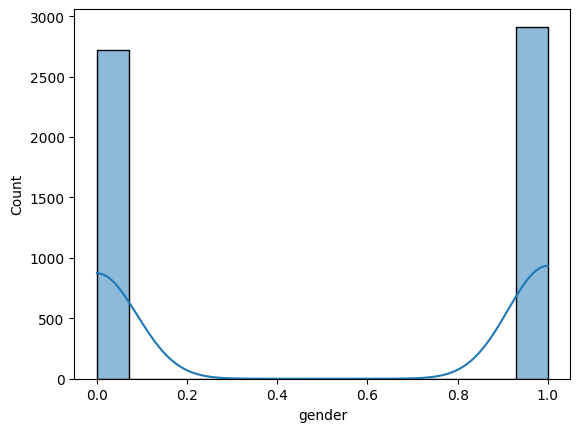

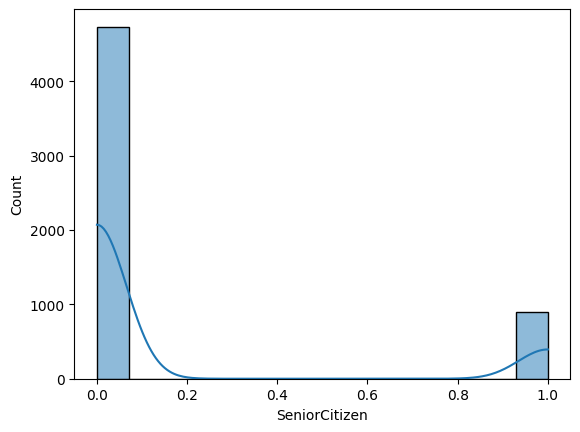

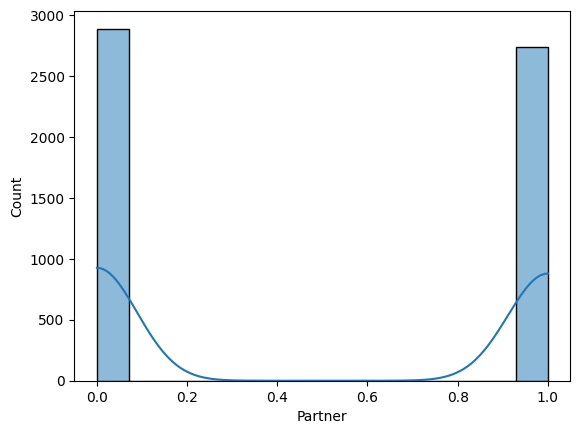

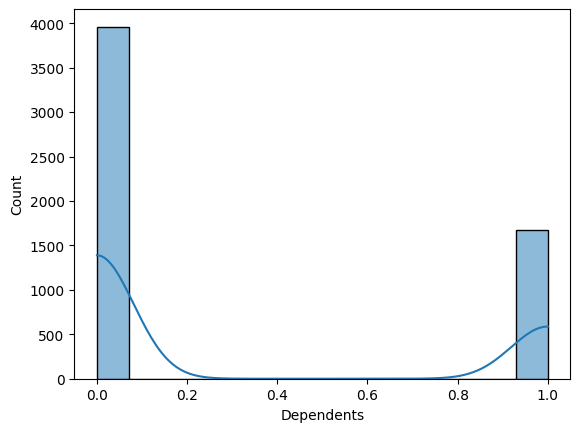

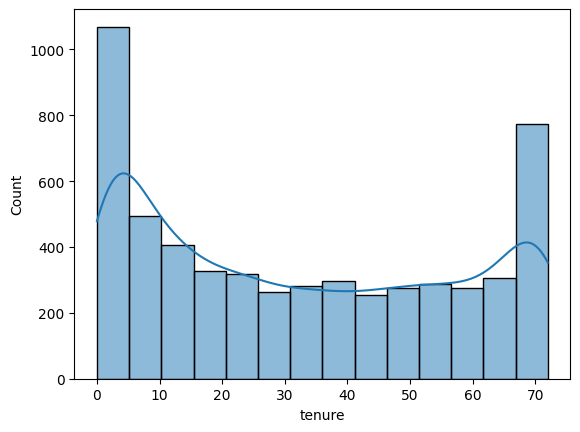

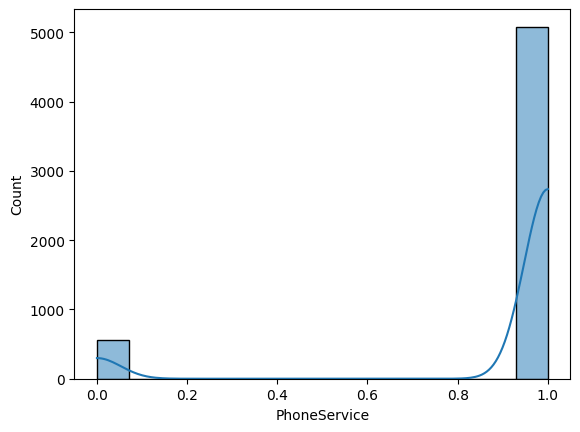

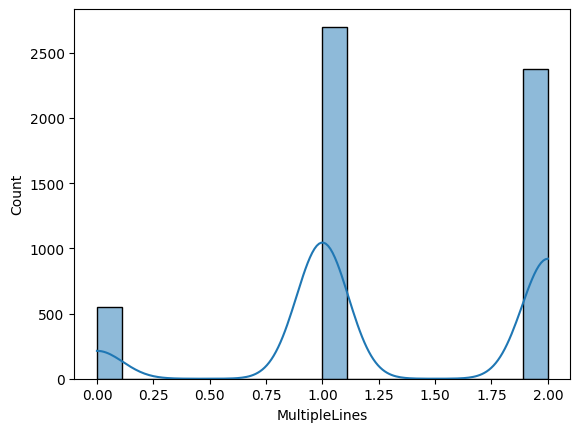

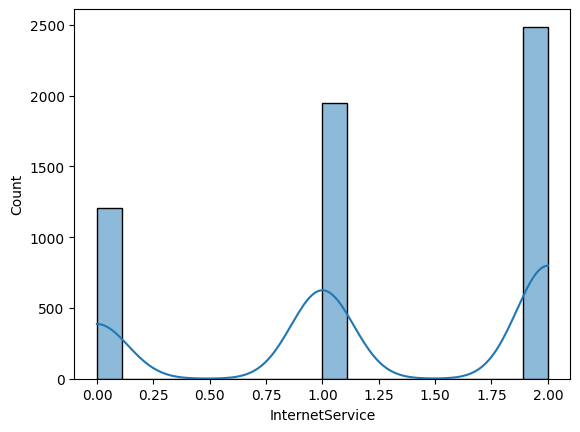

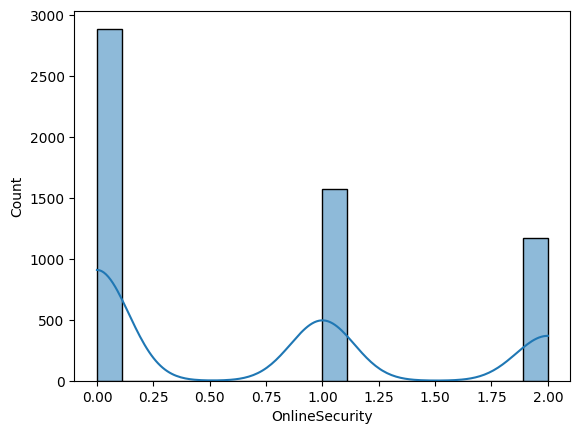

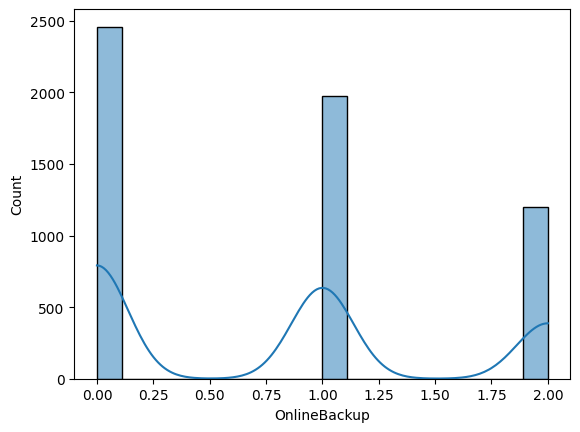

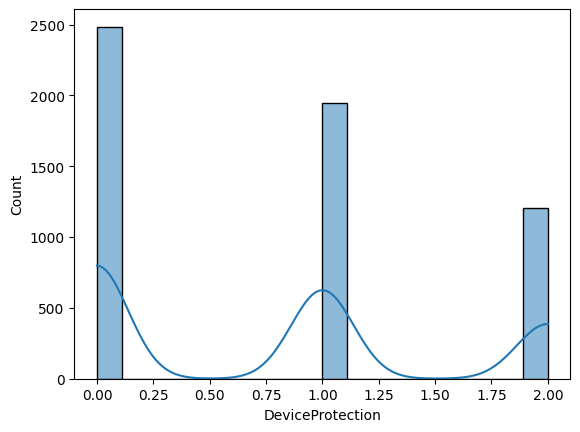

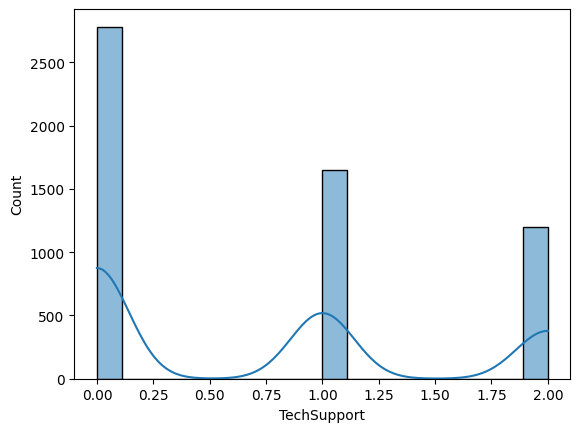

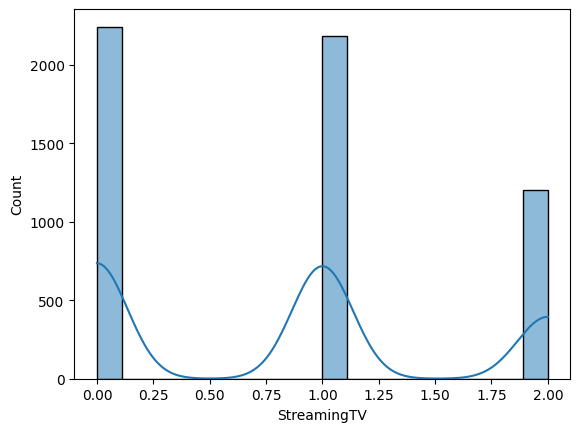

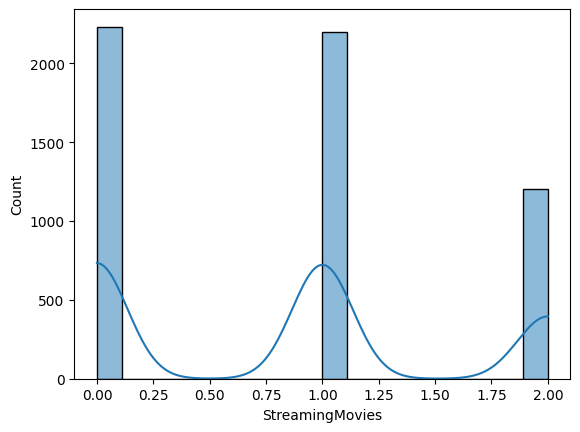

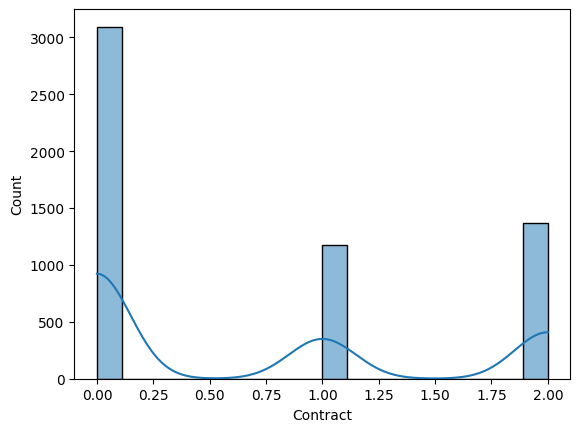

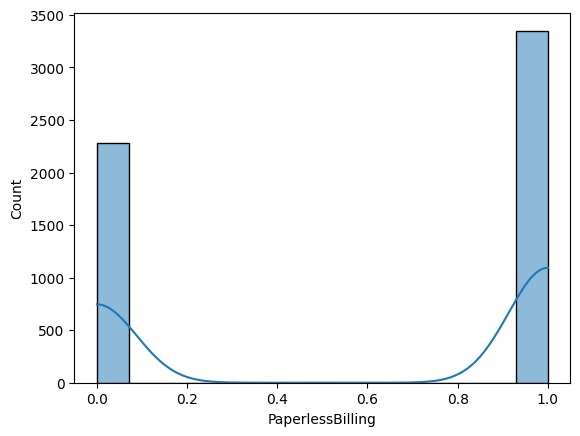

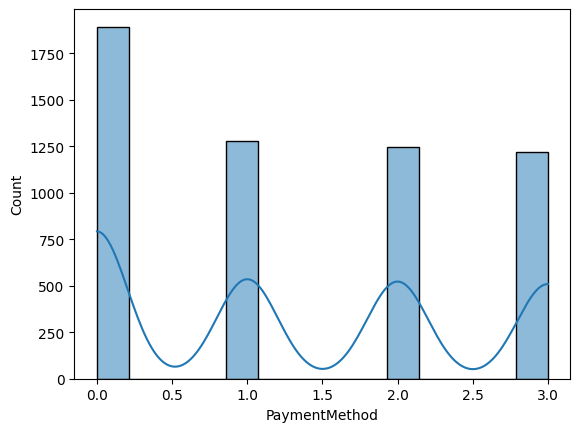

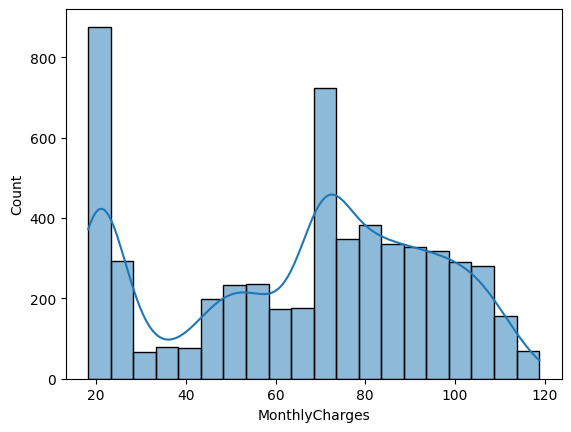

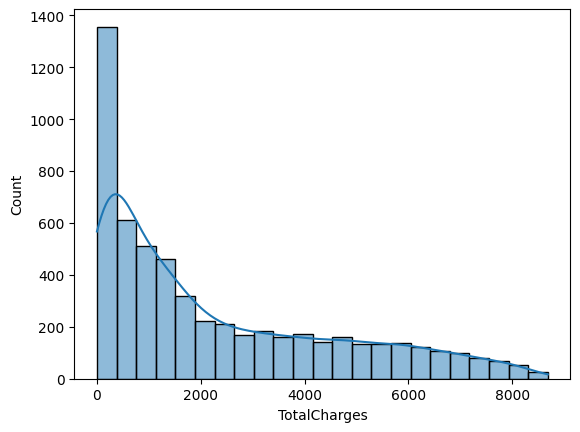

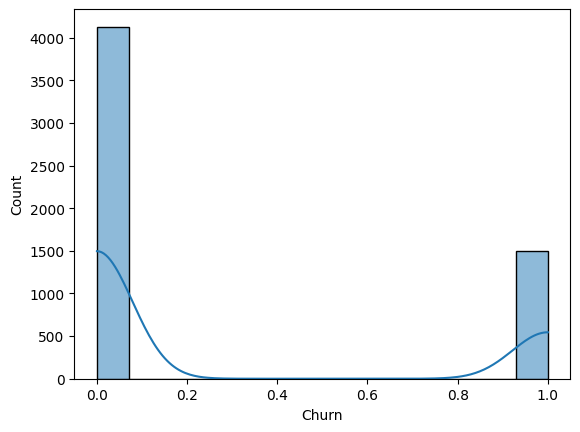

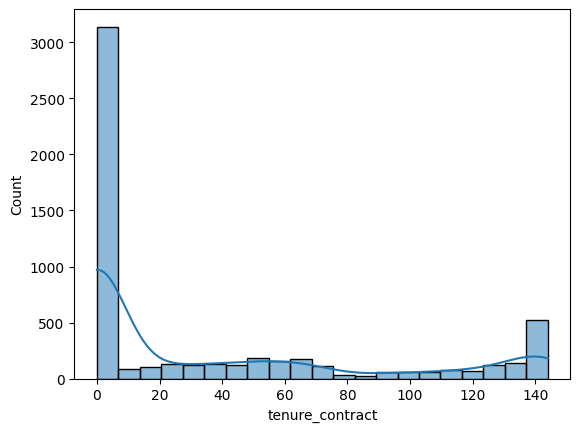

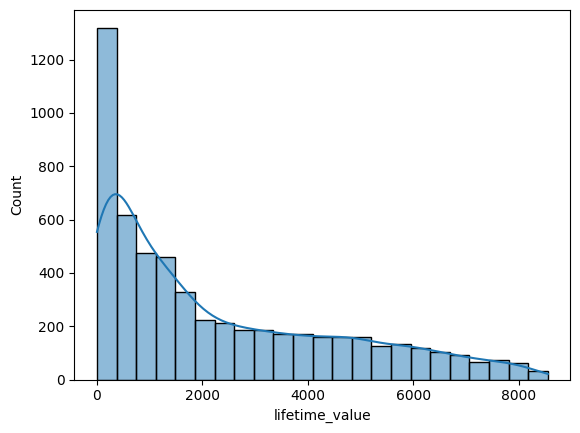

In [515]:
for i in train_df.columns:
  sns.histplot(train_df[i],kde=True)
  plt.show()


In [516]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [517]:
x_train

array([[1.        , 0.        , 1.        , ..., 0.0398388 , 0.05555556,
        0.04065497],
       [0.        , 0.        , 0.        , ..., 0.15992021, 0.94444444,
        0.15946199],
       [1.        , 0.        , 0.        , ..., 0.09541133, 0.        ,
        0.10094737],
       ...,
       [0.        , 0.        , 1.        , ..., 0.05850711, 0.        ,
        0.05976608],
       [1.        , 0.        , 1.        , ..., 0.41125633, 0.59722222,
        0.39806433],
       [0.        , 1.        , 1.        , ..., 0.82008544, 0.46527778,
        0.82750877]])

In [518]:
# feature selection with kbest
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
best_features = SelectKBest(score_func=chi2, k=10)
fit = best_features.fit(x_train, y_train)

In [519]:
# to use logistic regression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.805678793256433
[[735  91]
 [128 173]]


In [520]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.805678793256433
[[735  91]
 [128 173]]


In [521]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.805678793256433
[[735  91]
 [128 173]]


In [522]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[]
neighbors = np.arange(3,20)

for i in neighbors:
  knn_model = KNeighborsClassifier(n_neighbors=i)
  knn_model.fit(x_train,y_train)
  y_pred_knn = knn_model.predict(x_test)
  metric_k.append(accuracy_score(y_test,y_pred_knn))

metric_k

[0.7622005323868678,
 0.7790594498669032,
 0.7772848269742679,
 0.7852706299911268,
 0.7781721384205856,
 0.7870452528837621,
 0.7755102040816326,
 0.7879325643300799,
 0.7790594498669032,
 0.7861579414374446,
 0.7834960070984915,
 0.7888198757763976,
 0.7870452528837621,
 0.7905944986690329,
 0.7879325643300799,
 0.7914818101153505,
 0.7888198757763976]

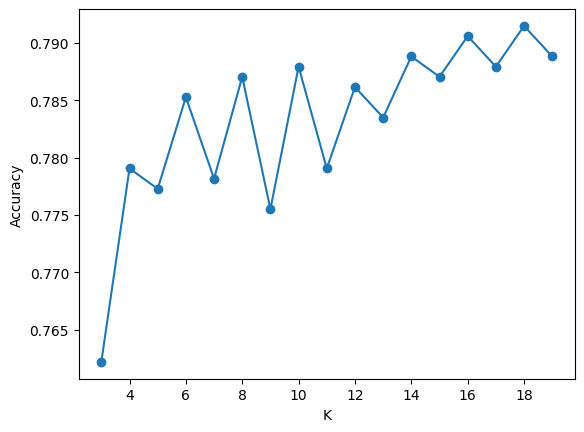

In [523]:
plt.plot(neighbors,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [524]:
knn_classifier = KNeighborsClassifier(n_neighbors=18)
knn_classifier.fit(x_train,y_train)
y_pred_knn = knn_classifier.predict(x_test)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7914818101153505
[[734  92]
 [143 158]]


In [525]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
param_grid = {'C':[0.1,1,10,100],'gamma':[1,0.1,0.01,0.001]}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(x_train,y_train)
grid_predictions = grid.predict(x_test)
print('Accuracy Score:')
print(accuracy_score(y_test,grid_predictions))
print('Confusion Matrix:')
print(confusion_matrix(y_test,grid_predictions))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   1.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.9s
[CV] END .....................................C=0.1, gamma=1; total time=   0.6s
[CV] END .....................................C=0.1, gamma=1; total time=   0.6s
[CV] END .....................................C=0.1, gamma=1; total time=   0.6s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.5s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.5s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.5s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.5s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.5s
[CV] END ..................................C=0.1

In [526]:
test_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374.00,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,Male,0,No,No,27,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,2516-VQRRV,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.40,Yes
1406,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,1722-LDZJS,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


In [527]:
test_df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [528]:


if "TotalCharges" in test_df.columns:
    test_df["TotalCharges"] = pd.to_numeric(
        test_df["TotalCharges"],
        errors="coerce"
    )

In [529]:
test_df['gender'] = test_df['gender'].fillna(test_df['gender'].mode()[0])
test_df['OnlineSecurity'] = test_df['OnlineSecurity'].fillna(test_df['OnlineSecurity'].mode()[0])
test_df['MonthlyCharges'] = test_df['MonthlyCharges'].fillna(test_df['MonthlyCharges'].median())
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(train_df['tenure'] * train_df['MonthlyCharges'])

In [530]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [531]:
test_df['gender'] = test_df['gender'].map({'Female':0,'Male':1})
test_df['Partner'] = test_df['Partner'].map({'No':0,'Yes':1})
test_df['Dependents'] = test_df['Dependents'].map({'No':0,'Yes':1})
test_df['PhoneService'] = test_df['PhoneService'].map({'No':0,'Yes':1})
test_df['PaperlessBilling'] = test_df['PaperlessBilling'].map({'No':0,'Yes':1})
test_df['Churn'] = test_df['Churn'].map({'No':0,'Yes':1})
test_df['MultipleLines'] = test_df['MultipleLines'].map({'No phone service':0,'No':1,'Yes':2})
test_df['InternetService'] = test_df['InternetService'].map({'No':0,'DSL':1,'Fiber optic':2})
test_df['OnlineSecurity'] = test_df['OnlineSecurity'].map({'No':0,'Yes':1,'No internet service':2})
test_df['OnlineBackup'] = test_df['OnlineBackup'].map({'No':0,'Yes':1,'No internet service':2})
test_df['DeviceProtection'] = test_df['DeviceProtection'].map({'No':0,'Yes':1,'No internet service':2})
test_df['TechSupport'] = test_df['TechSupport'].map({'No':0,'Yes':1,'No internet service':2})
test_df['StreamingTV'] = test_df['StreamingTV'].map({'No':0,'Yes':1,'No internet service':2})
test_df['StreamingMovies'] = test_df['StreamingMovies'].map({'No':0,'Yes':1,'No internet service':2})
test_df['Contract'] = test_df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})
test_df['PaymentMethod'] = test_df['PaymentMethod'].map({'Electronic check':0,'Mailed check':1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})


In [532]:
test_df
test_df.drop('customerID', axis=1, inplace=True)

In [533]:
test_df['tenure_contract'] = test_df['tenure'] * test_df['Contract']
test_df['lifetime_value'] = test_df['tenure'] * test_df['MonthlyCharges']


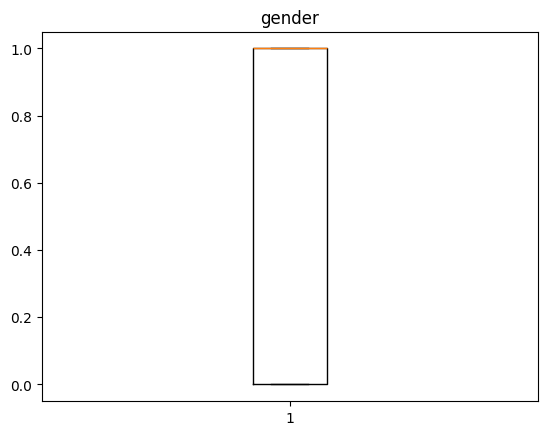

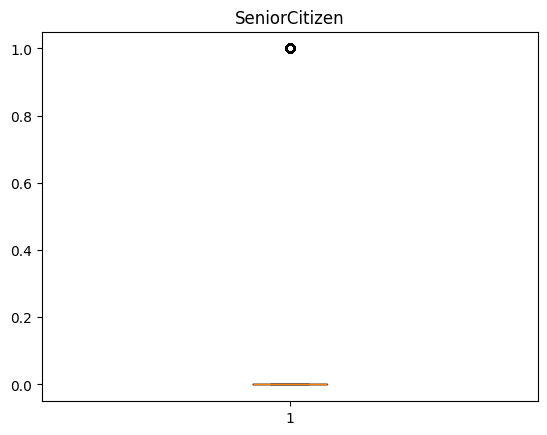

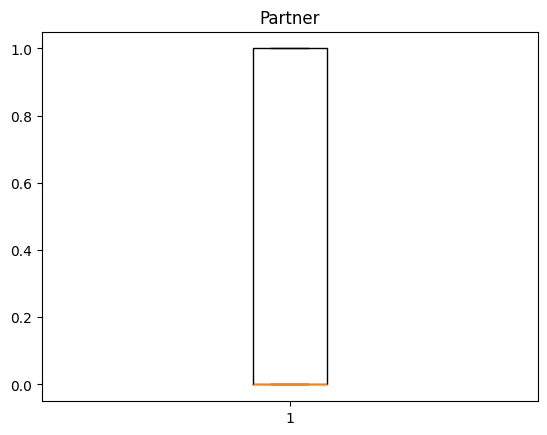

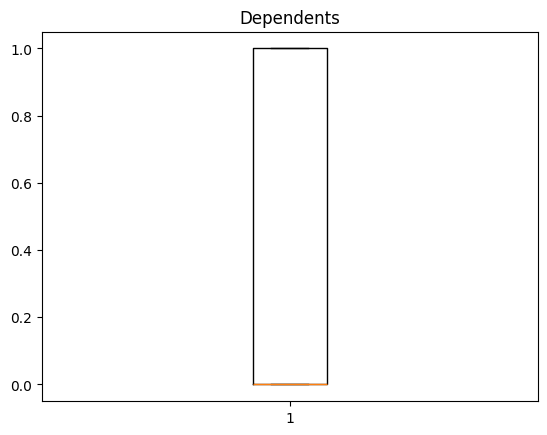

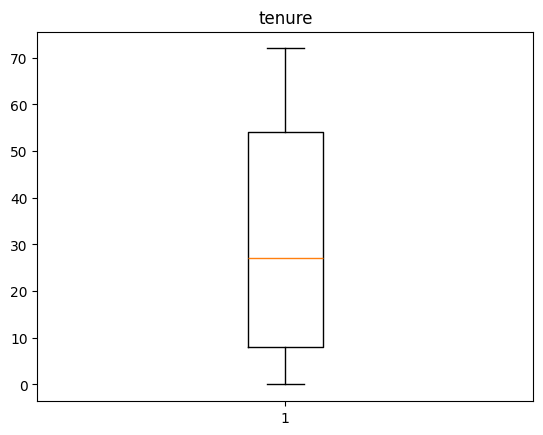

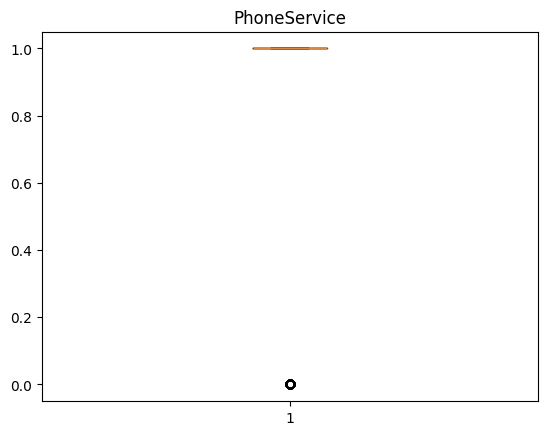

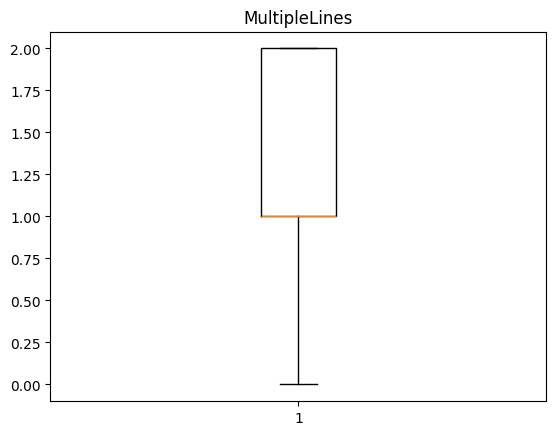

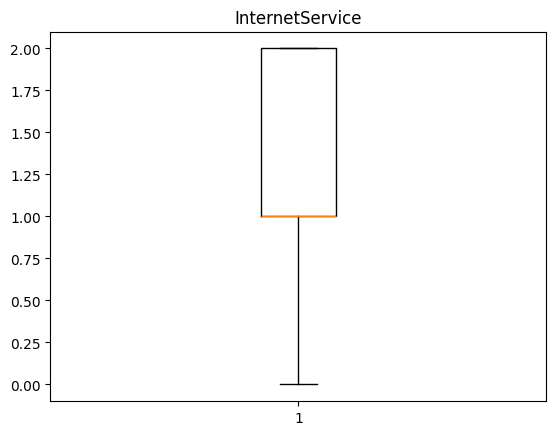

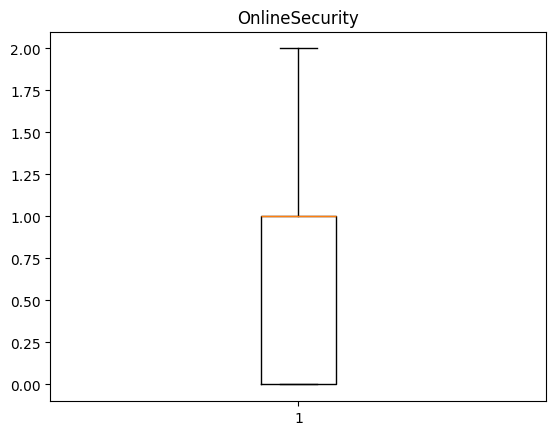

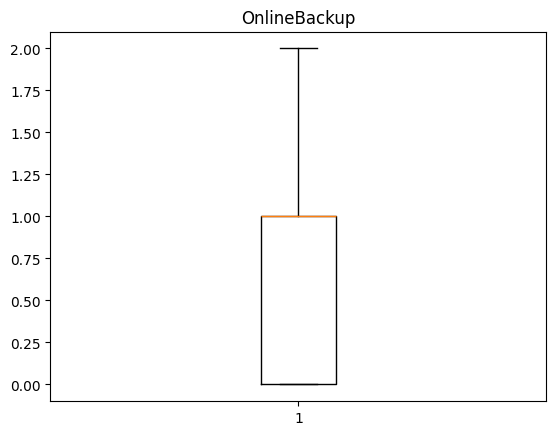

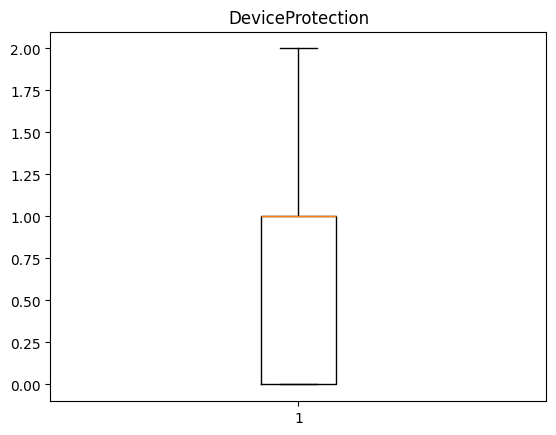

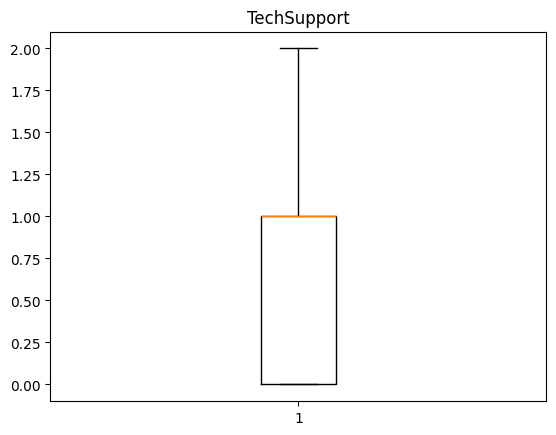

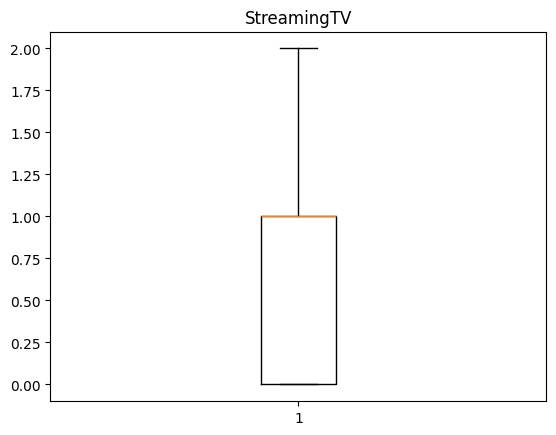

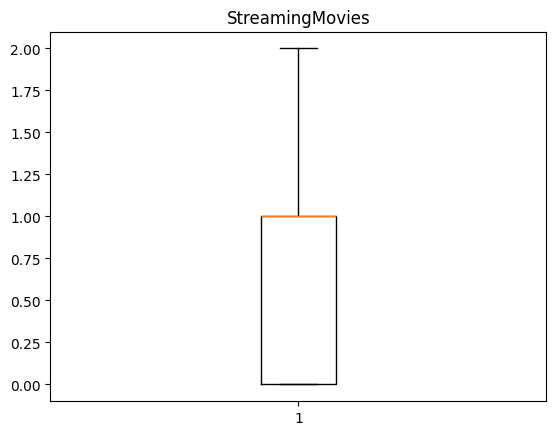

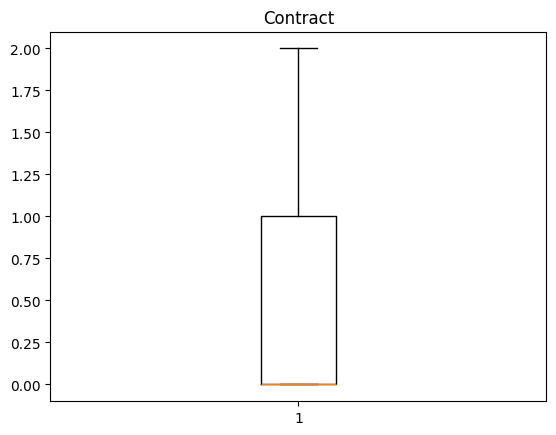

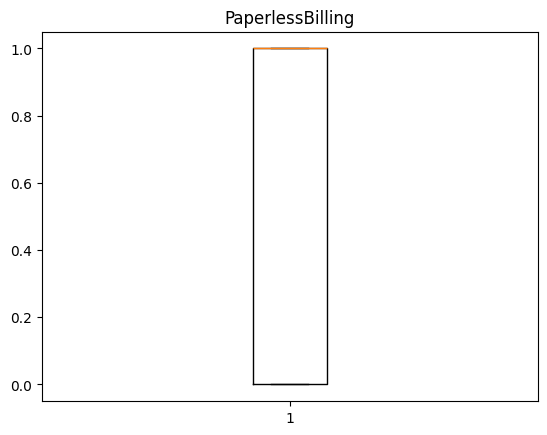

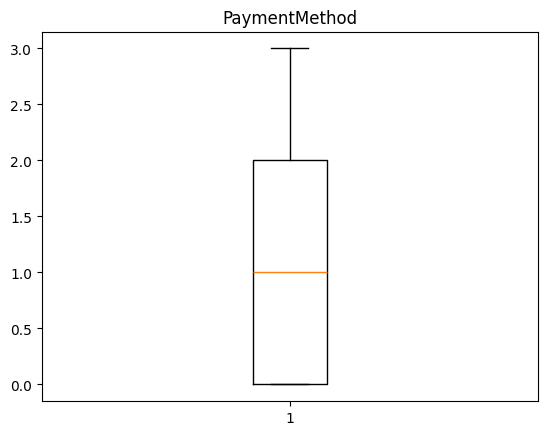

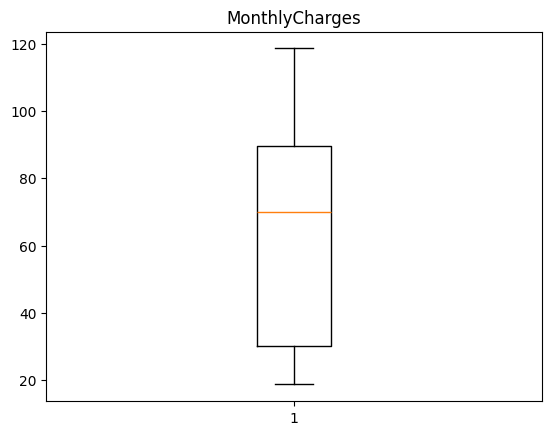

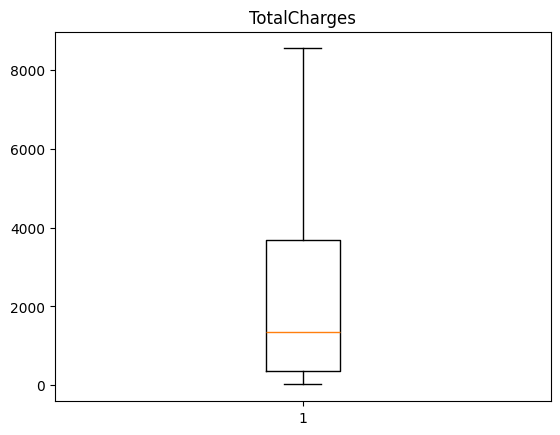

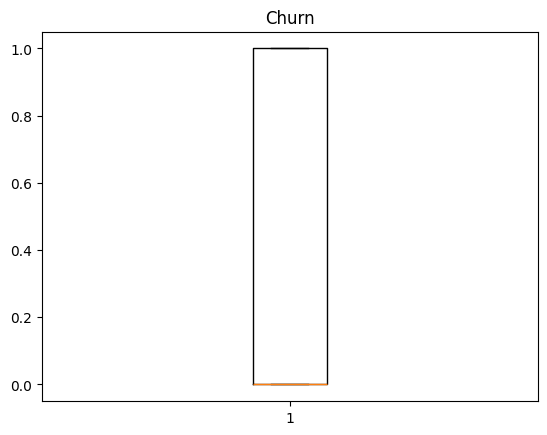

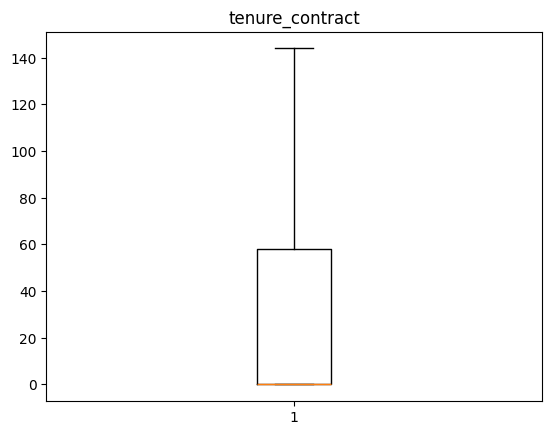

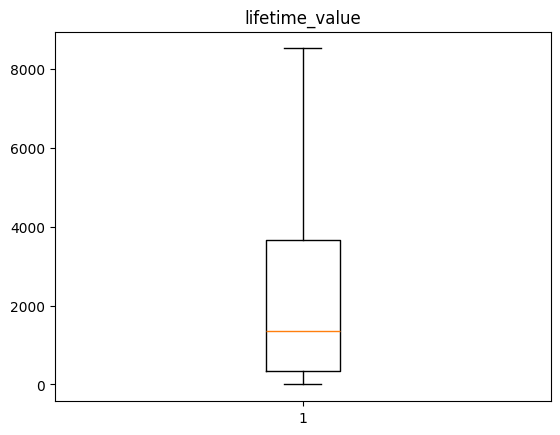

In [534]:
columns = test_df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(test_df[i])
  plt.title(i)
  plt.show()

In [535]:
x=test_df.drop('Churn',axis=1)
y=test_df['Churn']
x_test,y_test = x,y

In [536]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_test = scaler.fit_transform(x_test)

In [537]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
best_features = SelectKBest(score_func=chi2, k=10)
fit = best_features.fit(x_test, y_test)

In [538]:
model = LogisticRegression()
model.fit(x_test,y_test)
y_pred = model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.815471965933286
[[962  82]
 [178 187]]


In [539]:
test_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_contract,lifetime_value
0,1,0,1,1,40,1,2,2,0,0,...,0,0,0,1,0,81.20,3292.30,0,0,3248.0
1,0,0,1,0,12,1,2,1,1,0,...,1,1,1,0,0,78.85,876.75,0,12,946.2
2,1,0,0,0,43,1,2,2,0,0,...,1,1,1,1,0,100.00,4211.55,1,43,4300.0
3,1,0,0,0,72,1,2,2,1,1,...,1,1,2,1,0,118.20,8547.15,0,144,8510.4
4,0,0,0,0,10,0,0,1,0,1,...,0,0,0,0,0,36.25,374.00,0,0,362.5
